# Sweep operating frequency of a cavity to trigger static ponderomotive instability

In [1]:
import os
import sys

cur_dir = os.getcwd()
root_dir = os.path.abspath(os.path.join(cur_dir, '..', '..'))
sys.path.append(root_dir)

import numpy as np
import matplotlib.pyplot as plt

import care

To prevent mechanical modes from making the static instability less obvious, we damp their contribution by significantly lowering their quality factors.

In [2]:
# --! specify cavity parameters --!

parser = care.create_args_parser()

args = parser.parse_args(
    args=[
        '-fg', '1.3e9',
        '-ig', '0.016',
        '-og', '-460.0',

        '-rc', '1036',
        '-qc', '3e6',

        '-ga', '12e6',

        '-fm', '280, 341, 460, 487, 618', # mechanical modes' frequencies
        '-qm', '2, 2, 2, 2, 2',           # heavily damp mechanical modes by setting their quality to 2
        '-km', '2, 0.8, 2, 0.6, 0.2',     # mechanical modes' coupling factors

        '-ib', '0.008',
        '-nb', '15000',

        '-nf', '5000',

        '-ts', '1e-6',
        '-ns', '35000',
    ]
)


### Instantiate cavity resonance simulator

In [3]:
# --! create cavity simulator --!

sim = care.simulator(args)

In [4]:
# --! simulate --!

def sim_foldover(sim, sim_nsample, f):

    sim.src.f = f
    vc = 0.0

    for i in range(sim_nsample):
        vc, _ = sim.step(0.0)

    return vc

### Sweep operating frequency from left to right

In [5]:
# --! run simulation from left to right --!

sim_nsample = 2048 * 16
og = np.arange(-500.0, 500.0, 1.0)
vc = np.zeros_like(og, dtype=complex)

for j, f in enumerate(og):
    vc[j] = sim_foldover(sim, sim_nsample, f)
    if j % 100 == 0:
        print(f'processed frequency {f}')

A jump in cavity voltage can be observed in a plot below.

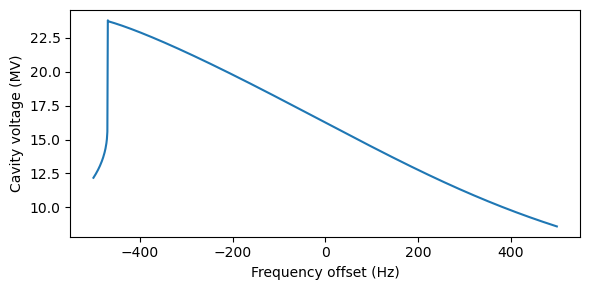

In [6]:
# --! plot simulation results --!

plt.figure(figsize=(6, 3))

plt.plot(og, abs(vc) * 1e-6)
plt.xlabel('Frequency offset (Hz)')
plt.ylabel('Cavity voltage (MV)')

plt.tight_layout()
plt.show()

### Sweep operating frequency from right to left

In [8]:
# --! run simulation from right to left --!

og_reversed = np.arange(500.0, -500.0, -1.0)
vc_reversed = np.zeros_like(og_reversed, dtype=complex)

sim.reset()

for j, f in enumerate(og_reversed):
    vc_reversed[j] = sim_foldover(sim, sim_nsample, f)
    if j % 100 == 0:
        print(f'processed frequency {f}')

processing frequency 500.0
processing frequency 400.0
processing frequency 300.0
processing frequency 200.0
processing frequency 100.0
processing frequency 0.0
processing frequency -100.0
processing frequency -200.0
processing frequency -300.0
processing frequency -400.0


No jump occurs when sweeping frequency in the opposite direction.

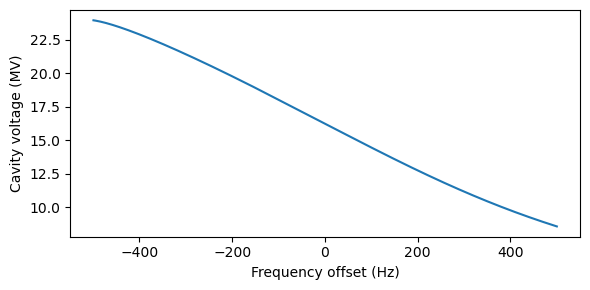

In [9]:
# --! plot simulation results --!

plt.figure(figsize=(6, 3))

plt.plot(og_reversed, abs(vc_reversed) * 1e-6)
plt.xlabel('Frequency offset (Hz)')
plt.ylabel('Cavity voltage (MV)')

plt.tight_layout()
plt.show()